In [1]:
import os

os.chdir("..")
os.getcwd()

'/home/borealis/Documents/work/projects/work_tests/SpeakVer'

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

In [3]:
# Paths
RUNS_PATH = "runs"

In [4]:
list_experiments = os.listdir(RUNS_PATH)
list_experiments

['exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_throat_mic',
 'exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_throat_mic_max_sr_4000000',
 'exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_all_type_mic',
 'exp2_sched_unfreeze_named_modules_batch64_epochs150_no_balance_cosanwarm_dyn_batch_all_type_mic',
 'exp2_sched_unfreeze_named_modules_batch64_epochs150_no_balance_cosanwarm_dyn_batch_throat_mic',
 'exp1_blocks4_batch64_epochs80_no_balance_plateausched_throat_mic',
 'exp1_blocks3_batch64_epochs80_no_balance_plateausched_throat_mic']

In [5]:
summaries = {}

for path in list_experiments:
    full_path = os.path.join(RUNS_PATH, path, "summary.json")

    with open(full_path, "rb") as file:
        summary = json.load(file)

    summaries[path] = summary

In [6]:
summaries

{'exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_throat_mic': {'finished': '2026-07-29T09:49:55.054566',
  'best_epoch': 99,
  'best_eer': 0.0416098355788227,
  'best_score': 0.11361808812714137,
  'epochs_completed': 100,
  'early_stopping': False},
 'exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_throat_mic_max_sr_4000000': {'finished': '2026-07-29T17:44:43.647141',
  'best_epoch': 97,
  'best_eer': 0.04645455823055318,
  'best_score': 0.11781822296979713,
  'epochs_completed': 100,
  'early_stopping': False},
 'exp1_sched_unfreeze_named_modules_batch64_epochs100_no_balance_cosanwarm_dyn_batch_all_type_mic': {'finished': '2026-07-29T20:21:51.300809',
  'best_epoch': 50,
  'best_eer': 0.07822074797673215,
  'best_score': 0.2008222547912669,
  'epochs_completed': 70,
  'early_stopping': True},
 'exp2_sched_unfreeze_named_modules_batch64_epochs150_no_balance_cosanwarm_dyn_batch_all_type_mic': {'finished': '2026-07-3

In [7]:
results_data1 = pd.DataFrame(
    {
        "names": list_experiments,
        "values": [val["best_eer"] for val in summaries.values()],
        "with_dyn_batch": [
            True if "dyn_batch" in i else False for i in list_experiments
        ],
        "all_type_mic": [
            True if "all_type_mic" in i else False for i in list_experiments
        ],
        "plateauscheduler": [
            True if "plateausched" in i else False for i in list_experiments
        ],
    }
)
results_data1

,names,values,with_dyn_batch,all_type_mic,plateauscheduler
0,exp1_sched_unfreeze_named_modules_batch64_epoc...,0.041610,True,False,False
1,exp1_sched_unfreeze_named_modules_batch64_epoc...,0.046455,True,False,False
2,exp1_sched_unfreeze_named_modules_batch64_epoc...,0.078221,True,True,False
3,exp2_sched_unfreeze_named_modules_batch64_epoc...,0.080219,True,True,False
4,exp2_sched_unfreeze_named_modules_batch64_epoc...,0.044086,True,False,False
5,exp1_blocks4_batch64_epochs80_no_balance_plate...,0.054160,False,False,True
6,exp1_blocks3_batch64_epochs80_no_balance_plate...,0.057984,False,False,True


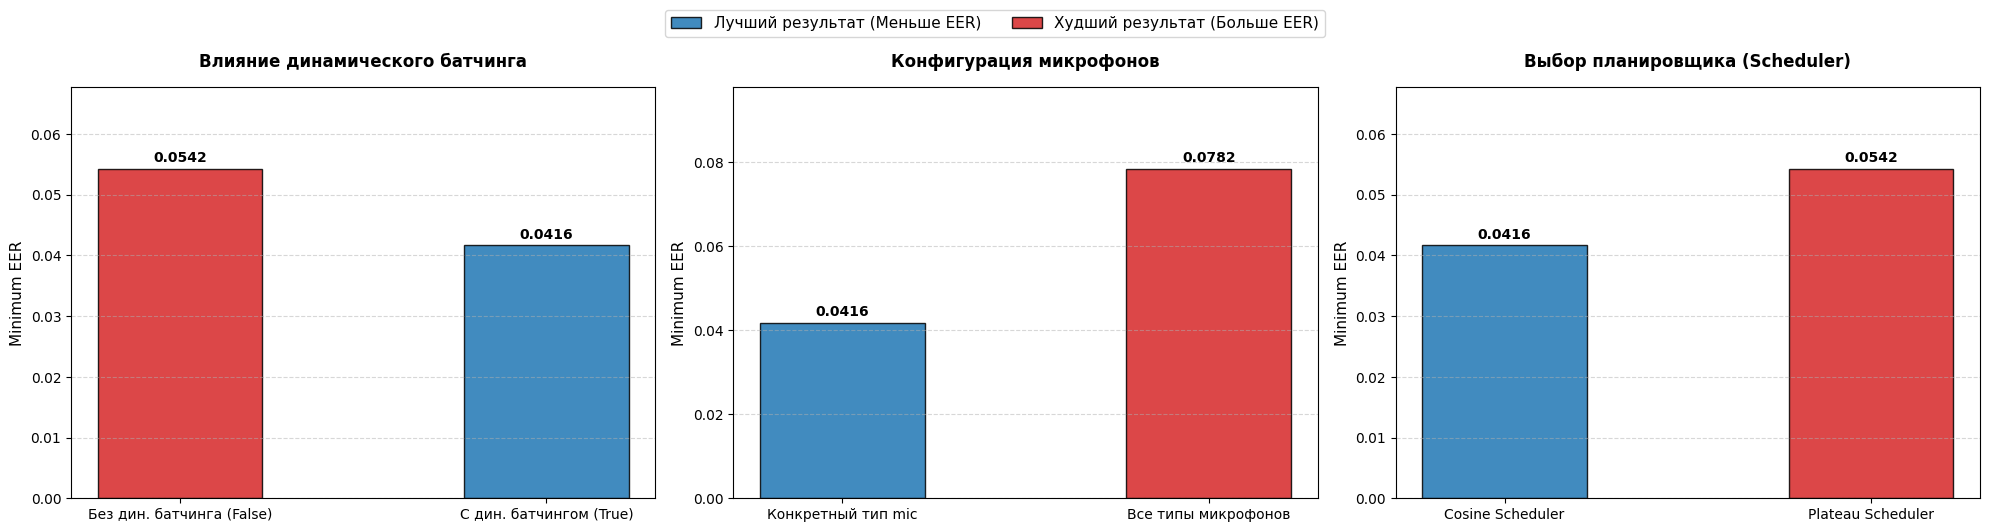

In [8]:
features = ["with_dyn_batch", "all_type_mic", "plateauscheduler"]
titles = [
    "Влияние динамического батчинга",
    "Конфигурация микрофонов",
    "Выбор планировщика (Scheduler)",
]

# Явно задаем текстовые подписи для каждого состояния [False, True]
feature_labels = {
    "with_dyn_batch": ["Без дин. батчинга (False)", "С дин. батчингом (True)"],
    "all_type_mic": ["Конкретный тип mic", "Все типы микрофонов"],
    "plateauscheduler": ["Cosine Scheduler", "Plateau Scheduler"]
}

# Создаем холст: 1 строка, 3 колонки
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Базовые цвета для логики
COLOR_WINNER = "#1f77b4"  # Синий (значение меньше)
COLOR_LOSER = "#d62728"   # Красный (значение больше)

for ax, feature, title in zip(axes, features, titles):
    # Агрегируем минимальный EER
    grouped = (
        results_data1.groupby(feature)["values"]
        .min()
        .reindex([False, True])
    )
    
    val_false = grouped[False]
    val_true = grouped[True]
    
    # Динамически определяем цвета (меньший EER — синий победитель)
    if pd.isna(val_false) or pd.isna(val_true):
        current_colors = [COLOR_LOSER, COLOR_WINNER]
    elif val_true < val_false:
        current_colors = [COLOR_LOSER, COLOR_WINNER]  # True выиграл (синий), False проиграл (красный)
    elif val_false < val_true:
        current_colors = [COLOR_WINNER, COLOR_LOSER]  # False выиграл (синий), True проиграл (красный)
    else:
        current_colors = [COLOR_WINNER, COLOR_WINNER] # Ничья

    x = np.arange(2)

    # Рисуем бары с кастомными цветами
    rects = ax.bar(
        x, 
        grouped.values, 
        width=0.45, 
        color=current_colors, 
        edgecolor="black", 
        alpha=0.85
    )

    # Добавляем точные значения над барами
    ax.bar_label(rects, padding=3, fmt="%.4f", fontsize=10, weight="bold")

    # Кастомизация текущего подграфика с новыми текстовыми метками
    ax.set_title(title, fontsize=12, pad=15, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(feature_labels[feature], fontsize=10)
    ax.set_ylabel("Minimum EER", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Динамический лимит оси Y под высоту текста
    max_val = grouped.max() if not pd.isna(grouped.max()) else 0.1
    ax.set_ylim(0, max_val * 1.25)

# Единая легенда для всей фигуры
legend_elements = [
    Patch(facecolor=COLOR_WINNER, edgecolor="black", alpha=0.85, label="Лучший результат (Меньше EER)"),
    Patch(facecolor=COLOR_LOSER, edgecolor="black", alpha=0.85, label="Худший результат (Больше EER)")
]
fig.legend(
    handles=legend_elements, 
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.07), 
    ncol=2, 
    fontsize=11
)

plt.tight_layout()
plt.show()

In [26]:
histories = {}

for path in list_experiments:
    full_path = os.path.join(RUNS_PATH, path, "history.csv")
    
    if os.path.exists(full_path):
        history_df = pd.read_csv(full_path)
        
        history_df.columns = history_df.columns.str.strip()
        
        histories[path] = history_df

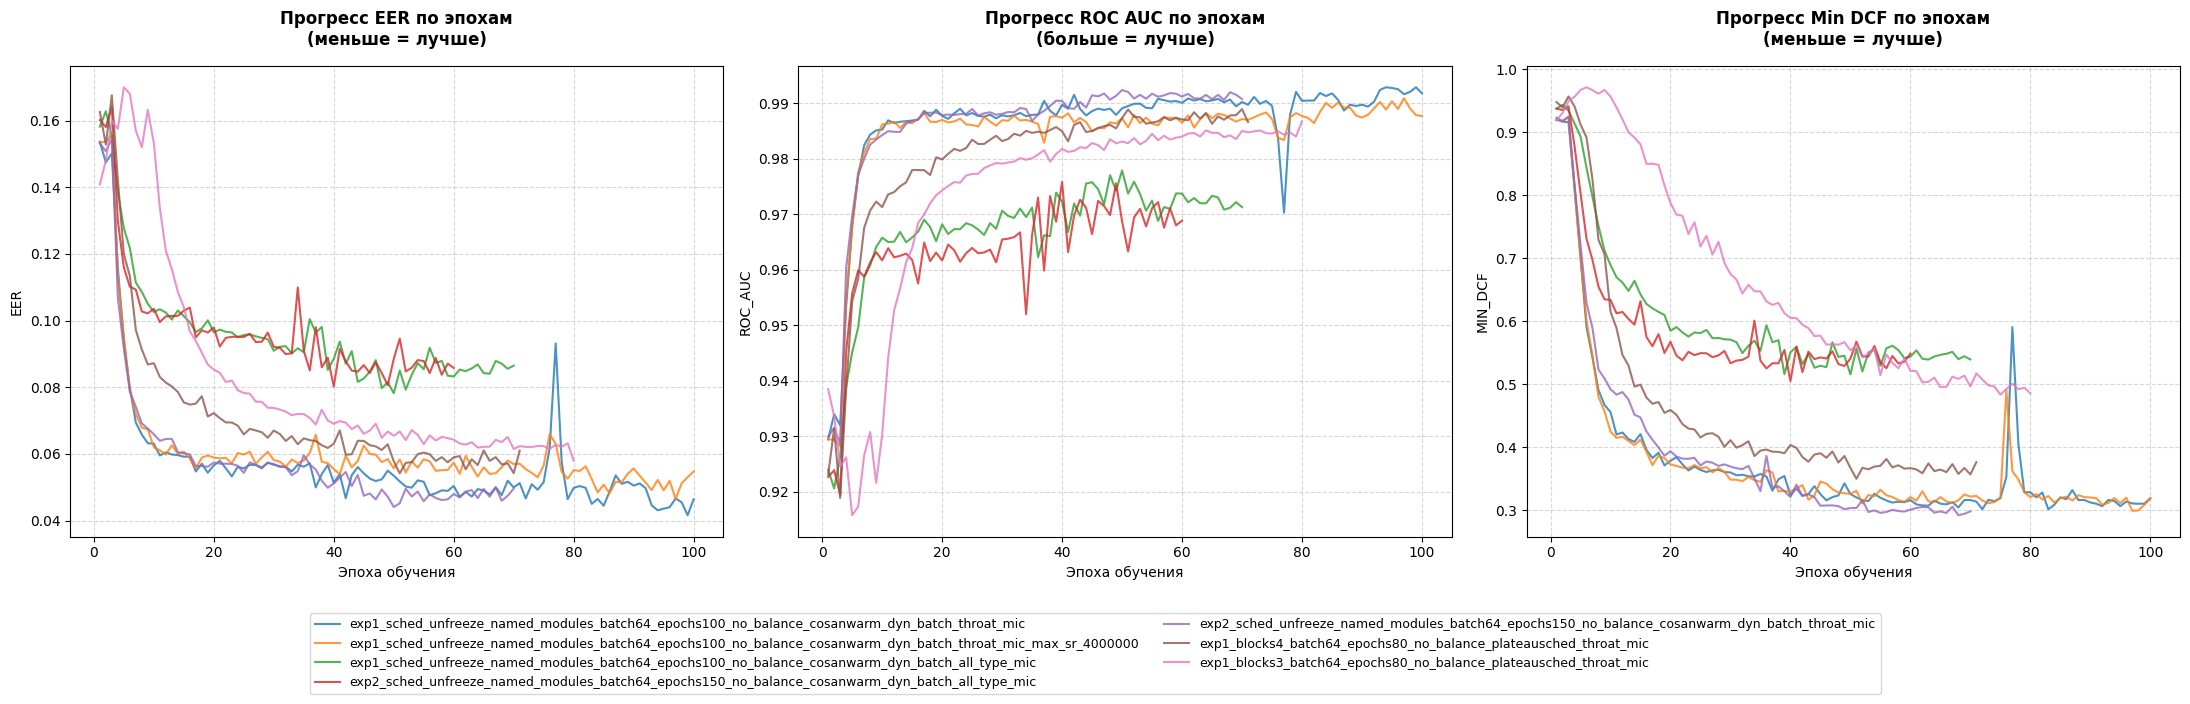

In [33]:
metrics_to_plot = ["eer", "roc_auc", "min_dcf"]
titles = [
    "Прогресс EER по эпохам\n(меньше = лучше)",
    "Прогресс ROC AUC по эпохам\n(больше = лучше)",
    "Прогресс Min DCF по эпохам\n(меньше = лучше)",
]

# 2. Создаем сетку из 3 графиков в один ряд с увеличенной шириной
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Очищаем колонки во всех датафреймах на всякий случай перед построением
for exp_name, df in histories.items():
    df.columns = df.columns.str.strip()

# 3. Итерируемся по метрикам и строим кривые обучения
for ax, metric, title in zip(axes, metrics_to_plot, titles):

    # Рисуем линию для каждого эксперимента из словаря histories
    for exp_name, df in histories.items():
        # Если в таблице есть колонка 'epoch', используем её как ось X, иначе индекс
        x_axis = df["epoch"] if "epoch" in df.columns else df.index

        ax.plot(x_axis, df[metric], label=exp_name, alpha=0.8, linewidth=1.5)

    # Настройка текущего подграфика
    ax.set_title(title, fontsize=12, pad=15, fontweight="bold")
    ax.set_xlabel("Эпоха обучения", fontsize=10)
    ax.set_ylabel(metric.upper(), fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

# 4. Выносим легенду со всеми экспериментами наружу (в самый низ всей фигуры)
# Это предотвратит перекрытие самих графиков длинными именами запусков
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=9,
)

# Автоматически выравниваем отступы
plt.tight_layout()
plt.show()
